# Injection-recovery validation (Catalog 2)

This notebook validates the six outlier-detection methods implemented in
`src/frb_anomaly/methods.py` (used identically in `02_methods_cat2.ipynb`) by
injection-recovery: synthetic anomalies of known type are injected into the real
Catalog 2 feature table, every method scores the augmented dataset without knowledge of
which rows are synthetic, and recovery is measured as the fraction of injected anomalies
ranked in the top 1/5/10% of the full ordering.

Repeater membership is deliberately not used as a validation signal. Repeaters form a
dense cluster in feature space rather than isolated outliers, so density- and
isolation-based detectors correctly do not flag them; recovering them would measure
cluster membership rather than anomaly sensitivity.

## Anomaly types injected

The injected families follow the Chandola, Banerjee and Kumar (2009) taxonomy:

- **Type A, global outlier.** `N_INJECT` independent points, each placed at
  `strength × D_MAX` from the data mean along an independent random direction, where
  `D_MAX` is the Euclidean distance of the most extreme real burst (FRB20220407A,
  8.26σ), plus a small independent Gaussian jitter (σ = 0.05 per feature) so the points
  are not confined to the exact surface of a sphere. Target detectors: EIF and kNN.
- **Type B, local outlier.** Each point is a real burst displaced individually (about four
  local-neighbour spacings, scaled by `strength`) into a nearby low-density pocket along an
  independent direction. The points are spread out and individually isolated relative to
  local density, not a shared clump, and are not globally extreme. Target detector: LOF.
- **Type C, collective / micro-cluster.** A single tight knot (σ = 0.05) of near-identical
  points embedded near the real distribution, its centre a real burst displaced `strength`
  local-neighbour spacings into a sparser pocket. The points sit at normal individual
  distances and are anomalous only through their collective over-density, so distance and
  density methods see normal local spacing while a cluster-based method can separate the
  knot. Target detector: CBLOF.
- **Type C2, resolvable collective.** A larger variant of the Type C knot: `cluster_size =
  80` near-identical points (`N_INJECT` is ignored here, since a collective anomaly's size
  is part of what defines it), its centre displaced `3 × strength` local-neighbour
  spacings off a real anchor, sized specifically to exceed both the density methods'
  neighbourhood scale and the cluster method's resolution. Tests whether a collective
  anomaly large enough to be structurally resolvable is still missed by non-cluster-based
  methods. Target detector: CBLOF.
- **Type D, subspace / correlation-breaking.** `sp_idx` and `sp_run` are set to individually
  normal values whose pairing violates the real `sp_idx`-`sp_run` correlation (r = −0.885);
  `strength` interpolates the joint relationship from normal through decorrelated to fully
  inverted. Both marginals stay within their normal range, so the point is odd only in the
  relationship and not in global distance. Target detector: the subspace ensemble.
- **Type E, contextual.** The observational context (DM, peak_freq) is kept from a real
  burst while the morphology is blended (by `strength`) toward a donor drawn from a distant
  context. The donor morphology is itself globally in-distribution, so the point is normal
  in both context and marginal morphology and is anomalous only in the
  morphology-given-context relationship. Target detector: CAD.

## Strength anchoring

The strength scale is per-type, not a single global ruler. For Type A it multiplies the
global-distance anchor `D_MAX`; for Type B it multiplies the local-neighbour spacing. For
Types C, C2, D and E it sets the size of the structural violation while keeping the point
globally un-extreme: the displacement of the embedded knot (C, C2), the degree of
correlation inversion (D), and the blend toward a distant-context morphology (E). Larger
strength makes the intended anomaly more pronounced in every case. The grid is
`{0.25, 0.5, 0.75, 1.0, 1.5, 2.0}`, with `N_REPEATS = 5` independent injection placements
per (type, strength) cell.

## Recovery metric

Recovery rate is the fraction of `N_INJECT = 20` injected anomalies (`cluster_size = 80`
for Type C2) ranked in the top X% of the augmented dataset, evaluated at X in {1%, 5%,
10%}. The headline threshold is top-5%. The sensitivity floor is the minimum strength at
which mean top-5% recovery reaches 0.50.

In [1]:
import sys
from pathlib import Path

PROJECT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT / 'src'))

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import warnings
warnings.filterwarnings('ignore')

# All six scorers come from frb_anomaly.methods, the same canonical, unit-tested
# implementation 02_methods_cat2.ipynb and 04_candidate_validation_cat2.ipynb use.
from frb_anomaly.methods import (
    lof_scores,
    eif_scores,
    knn_scores,
    cblof_scores,
    subspace_scores,
    cad_scores,
)

scaled = pd.read_csv(
    PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog2_features_scaled.csv'
)
scaled['is_repeater'] = scaled['is_repeater'].astype(str).str.lower() == 'true'

id_cols = ['tns_name', 'sub_num', 'is_repeater', 'repeater_name', 'catalog1_flag']
feature_cols = [c for c in scaled.columns if c not in id_cols]
X_real = scaled[feature_cols].values
N_REAL, N_FEATURES = X_real.shape

# Number of synthetic anomalies injected per trial.
N_INJECT = 20

print(f'Loaded {N_REAL} sub-burst rows, {N_FEATURES} features')
print(f'Features: {feature_cols}')

Loaded 4109 sub-burst rows, 8 features
Features: ['dm_fitb', 'width_fitb', 'flux', 'fluence', 'sp_idx', 'sp_run', 'peak_freq', 'bandwidth']


## Empirical calibration

Measure the real data extremes that anchor the strength scale for each anomaly type, and
fix the context/behaviour column split (DM and peak frequency as context, the rest as
morphology) used by the CAD anchor below and by `run_methods`.

In [2]:
# Global-distance anchor (Type A)
mu = X_real.mean(axis=0)
global_dists = np.linalg.norm(X_real - mu, axis=1)
D_MAX = global_dists.max()
D_MAX_BURST = scaled.iloc[global_dists.argmax()]['tns_name']

# kNN-distance anchor (Type C): mean distance to k=20 nearest neighbours, via the shared
# knn_scores implementation.
knn_scores_real = knn_scores(X_real, k=20)
KNN_MAX = knn_scores_real.max()
KNN_MAX_IDX = knn_scores_real.argmax()
KNN_MAX_BURST = scaled.iloc[KNN_MAX_IDX]['tns_name']

# Context/behaviour split, used below for the CAD anchor and by run_methods.
# Contextual: DM and peak_freq are the observational context; the rest is morphology.
CONTEXT_COLS = ['dm_fitb', 'peak_freq']
ctx_idx = [feature_cols.index(c) for c in CONTEXT_COLS]
beh_idx = [i for i in range(N_FEATURES) if i not in ctx_idx]

# CAD anchor (Type E): CAD scores for the real bursts, via the shared cad_scores
# implementation.
cad_real = cad_scores(X_real, ctx_idx, beh_idx, k=50)
CAD_MAX = cad_real.max()
CAD_MAX_BURST = scaled.iloc[cad_real.argmax()]['tns_name']

# Type D parameters: the sp_idx-sp_run correlation (r = -0.885) and its residual scale.
R_SP = -0.885
RESIDUAL_STD = np.sqrt(1 - R_SP ** 2)   # ~0.466
SP_IDX_I = feature_cols.index('sp_idx')
SP_RUN_I = feature_cols.index('sp_run')

print(f'D_MAX   = {D_MAX:.2f}   ({D_MAX_BURST})   [Type A anchor]')
print(f'KNN_MAX = {KNN_MAX:.2f}   ({KNN_MAX_BURST})   [Type C anchor]')
print(f'CAD_MAX = {CAD_MAX:.2f}   ({CAD_MAX_BURST})   [Type E anchor]')
print(f'sp_run residual std (Type D): {RESIDUAL_STD:.3f}')

D_MAX   = 8.26   (FRB20220407A)   [Type A anchor]
KNN_MAX = 4.54   (FRB20220407A)   [Type C anchor]
CAD_MAX = 8.25   (FRB20210909B)   [Type E anchor]
sp_run residual std (Type D): 0.466


## Method runner

`run_methods` scores an augmented feature matrix `X` with all six shared scorers from
`frb_anomaly.methods` and returns a dict of score arrays, where a higher score denotes a
more anomalous burst for every method. Two calls pass different keyword arguments than
`02_methods_cat2.ipynb`'s defaults, to bound runtime over the 180 trials: LOF is called
with a single neighbourhood size (`k=75`) rather than the notebook's five-way sweep, and
the subspace ensemble is called with 20 bagging iterations rather than 50. These are
argument differences on the same functions notebook 02 uses, not separate code.

In [3]:
def run_methods(X):
    """Score all bursts in X with all six methods. Returns dict of score arrays."""
    # All six scorers come from frb_anomaly.methods, the same functions
    # 02_methods_cat2.ipynb and 04_candidate_validation_cat2.ipynb call. LOF and the
    # subspace ensemble are called with the runtime-bounded settings described above;
    # everything else uses the shared defaults.
    scores = {}

    scores['lof'] = lof_scores(X, k=75)
    scores['eif'] = eif_scores(X)
    scores['knn'] = knn_scores(X)
    scores['cblof'] = cblof_scores(X)

    # Subspace ensemble: mean and max aggregation are both scored, from the same seed, so
    # both are computed over identical random subspaces and are directly comparable to
    # each other. This runs the 20-subspace LOF ensemble twice per trial.
    scores['subspace'] = subspace_scores(X, seed=42, agg='mean', n_subspaces=20, k=20)
    scores['subspace_max'] = subspace_scores(X, seed=42, agg='max', n_subspaces=20, k=20)

    scores['cad'] = cad_scores(X, ctx_idx, beh_idx, k=50)

    return scores

## Anomaly generators

One generator per anomaly geometry, imported from `src/frb_anomaly/injection.py` (extracted
so they can be unit-tested). A `Calibration` binds them to this dataset; each is then a pure
callable of `n` (count), `strength` (the per-type multiplier) and `rng` (a seeded Generator),
returning an array of injected feature rows to append to the real table. Per-type behaviour is
described in the introduction above.

In [4]:
# The anomaly generators live in src/frb_anomaly/injection.py so they can be unit-tested.
# A Calibration binds the dataset-derived quantities (computed above) into each generator,
# which then becomes a pure callable of (n, strength, rng). make_generators returns the
# name -> callable map the harness iterates over.
from frb_anomaly.injection import Calibration, make_generators

cal = Calibration(
    X_real=X_real, mu=mu, d_max=float(D_MAX), r_sp=R_SP,
    sp_idx_i=SP_IDX_I, sp_run_i=SP_RUN_I,
    context_idx=tuple(ctx_idx), behaviour_idx=tuple(beh_idx),
)
GENERATORS = make_generators(cal)
print('Generators:', list(GENERATORS))

Generators: ['A_global', 'B_local', 'C_collective', 'C_separated', 'D_subspace', 'E_contextual']


## Recovery measurer

Given a score dict and a boolean mask marking which rows are injected anomalies,
returns the fraction of injected anomalies landing in each top-X% tier.

In [5]:
# The recovery metric lives in src/frb_anomaly/injection.py so it can be unit-tested.
from frb_anomaly.injection import measure_recovery

## Diagnostic: real and injected data together

This step constructs one augmented dataset per anomaly type at a single fixed strength,
writes the real and injected rows to a CSV (tagged with an `is_injected` flag and an
`injected_type` label), and projects both populations into a 2D PCA space fitted on the
real data, so the injected points can be inspected against the real distribution. At
`DIAG_STRENGTH = 1.0` the Type A and B points should lie toward the edges of the distribution; the Type C, D
and E points are anomalous only in structure a 2D projection does not capture, so they may
sit within the bulk, which is expected. The per-type recovery line confirms that each target
detector flags its corresponding geometry before the full harness is run.

Saved real+injected table (4289 rows, 180 injected) to data/processed/phase_1/catalog2_injection_example.csv

Top-5% recovery at strength=1.0 (target detector in brackets):
  A_global       [eif      ]  1.00
  B_local        [lof      ]  0.90
  C_collective   [cblof    ]  0.00
  C_separated    [cblof    ]  0.00
  D_subspace     [subspace ]  0.30
  E_contextual   [cad      ]  0.25


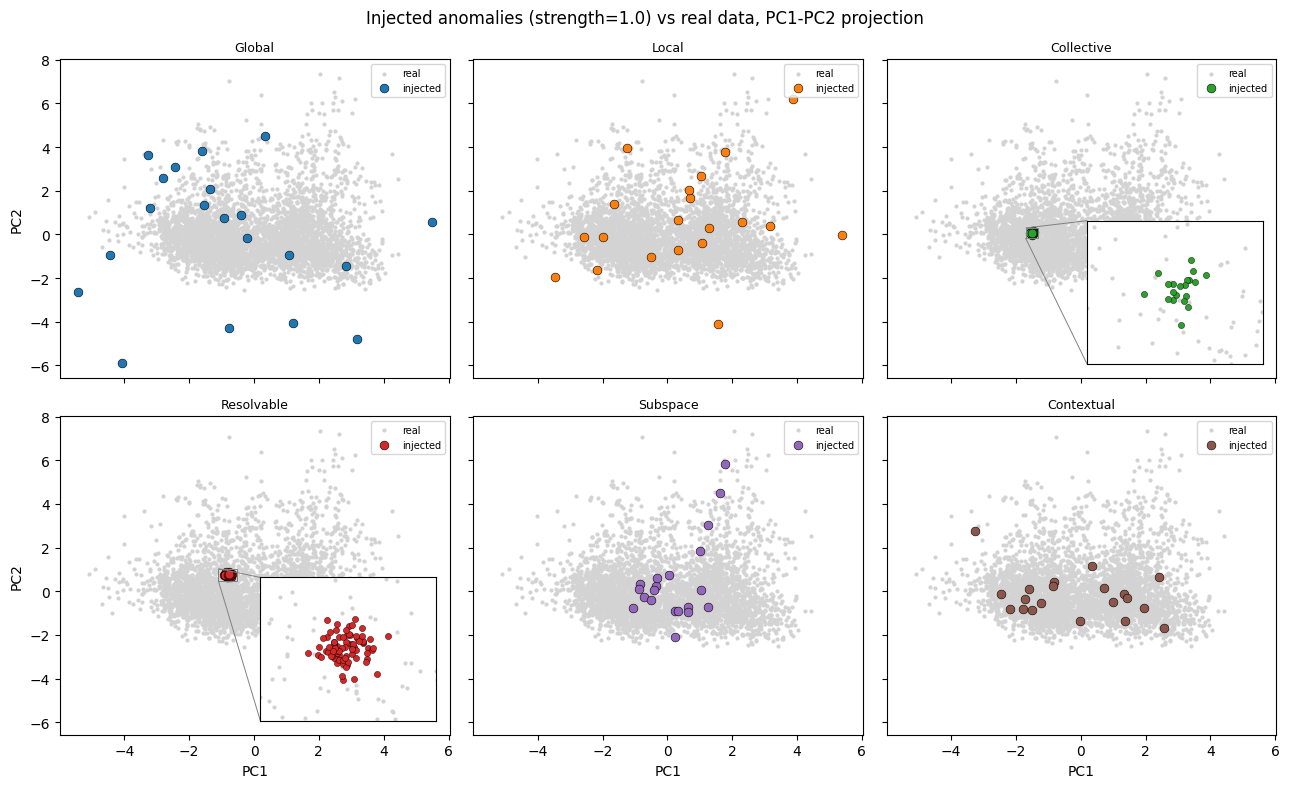

Saved: reports/Phase 1/figures/injection_pca_check.png


In [6]:
# Construct, save and visualise one augmented dataset per anomaly type so the real and
# injected populations can be inspected together before the full harness is run. The
# combined table is cached: set REBUILD_DIAGNOSTIC = True to regenerate it after any change
# to a generator, otherwise the cached file is reused and the per-type scoring is skipped.
REBUILD_DIAGNOSTIC = True

DIAG_STRENGTH = 1.0

# Pulled straight from the default matplotlib cycle rather than hardcoded, this dict is only
# used in this one figure, so there's no cross-plot consistency requirement to pin the exact
# hex values down for.
DEFAULT_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
TYPE_COLORS = {name: DEFAULT_CYCLE[i] for i, name in enumerate(GENERATORS)}
TYPE_TITLES = {
    'A_global': 'Global', 'B_local': 'Local',
    'C_collective': 'Collective', 'C_separated': 'Resolvable',
    'D_subspace': 'Subspace', 'E_contextual': 'Contextual',
}
TARGET_METHOD = {
    'A_global': 'eif', 'B_local': 'lof', 'C_collective': 'cblof',
    'D_subspace': 'subspace', 'E_contextual': 'cad', 'C_separated': 'cblof',
}

combined_path = PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog2_injection_example.csv'

# 2D PCA fitted on the real data only, so the projection is defined by real structure;
# injected points are transformed into that same space.
pca = PCA(n_components=2).fit(X_real)
real_2d = pca.transform(X_real)

if combined_path.exists() and not REBUILD_DIAGNOSTIC:
    # Reuse the cached table; the per-type recovery scoring is skipped on this path.
    combined = pd.read_csv(combined_path)
    injected_2d = {
        t: pca.transform(combined.loc[combined['injected_type'] == t, feature_cols].values)
        for t in GENERATORS
    }
    print(f'Loaded cached table from {combined_path.relative_to(PROJECT)} '
          f'({len(combined)} rows). Set REBUILD_DIAGNOSTIC = True to regenerate.')
else:
    # Build one augmented dataset per type, score it, and record top-5% recovery for the
    # target detector, then write the combined table to disk.
    combined_parts = [pd.DataFrame(X_real, columns=feature_cols).assign(
        injected_type='real', is_injected=False)]
    injected_2d = {}
    sanity = []
    for type_name, gen_fn in GENERATORS.items():
        rng = np.random.default_rng(12345 + ord(type_name[0]))
        anomalies = gen_fn(N_INJECT, DIAG_STRENGTH, rng)
        combined_parts.append(pd.DataFrame(anomalies, columns=feature_cols).assign(
            injected_type=type_name, is_injected=True))
        injected_2d[type_name] = pca.transform(anomalies)

        X_aug = np.vstack([X_real, anomalies])
        mask = np.zeros(len(X_aug), dtype=bool)
        mask[N_REAL:] = True
        sanity.append((type_name, measure_recovery(run_methods(X_aug), mask)))

    combined = pd.concat(combined_parts, ignore_index=True)
    combined.to_csv(combined_path, index=False)
    print(f'Saved real+injected table ({len(combined)} rows, '
          f'{int(combined["is_injected"].sum())} injected) to {combined_path.relative_to(PROJECT)}')

    print(f'\nTop-5% recovery at strength={DIAG_STRENGTH} (target detector in brackets):')
    for type_name, rec in sanity:
        m = TARGET_METHOD[type_name]
        print(f'  {type_name:14s} [{m:9s}]  {rec[m]["top5pct"]:.2f}')

# PCA scatter: one panel per type, real in grey, injected coloured, 2x3 rather than 1x6 so
# each panel gets more room. Types C and C2 (tight micro-clusters) get a zoomed inset, since at
# full-population scale a cluster of near-identical points collapses to what looks like a
# single dot.
INSET_TYPES = {'C_collective', 'C_separated'}

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
fig.suptitle(f'Injected anomalies (strength={DIAG_STRENGTH}) vs real data, '
             f'PC1-PC2 projection', fontsize=12)
for idx, (ax, type_name) in enumerate(zip(axes.flat, GENERATORS)):
    ax.scatter(real_2d[:, 0], real_2d[:, 1], s=4, c='lightgrey', label='real')
    inj = injected_2d[type_name]
    ax.scatter(inj[:, 0], inj[:, 1], s=40, c=TYPE_COLORS[type_name],
               edgecolor='k', linewidth=0.4, label='injected')
    ax.set_title(TYPE_TITLES[type_name], fontsize=9)
    ax.legend(fontsize=7, loc='best')
    if idx >= 3:
        ax.set_xlabel('PC1')
    if idx % 3 == 0:
        ax.set_ylabel('PC2')

    if type_name in INSET_TYPES:
        # Zoom to the injected cluster's own bounding box (plus margin) so its individual
        # points resolve as a scatter instead of one merged dot.
        margin = 0.6 * max(np.ptp(inj[:, 0]), np.ptp(inj[:, 1]), 0.1)
        x0, x1 = inj[:, 0].min() - margin, inj[:, 0].max() + margin
        y0, y1 = inj[:, 1].min() - margin, inj[:, 1].max() + margin
        axins = inset_axes(ax, width='45%', height='45%', loc='lower right', borderpad=1)
        axins.scatter(real_2d[:, 0], real_2d[:, 1], s=4, c='lightgrey')
        axins.scatter(inj[:, 0], inj[:, 1], s=20, c=TYPE_COLORS[type_name],
                       edgecolor='k', linewidth=0.3)
        axins.set_xlim(x0, x1)
        axins.set_ylim(y0, y1)
        axins.set_xticks([])
        axins.set_yticks([])
        mark_inset(ax, axins, loc1=2, loc2=3, fc='none', ec='0.5', lw=0.7)


plt.tight_layout()
fig_path = PROJECT / 'reports' / 'Phase 1' / 'figures' / 'injection_pca_check.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.relative_to(PROJECT)}')


## Harness

Outer loop over (anomaly type, strength, repeat). Each trial generates the anomalies,
appends them to the real feature table, scores the augmented table with all six methods,
and measures recovery; results accumulate into a single DataFrame.

With 6 types × 6 strengths × 5 repeats = 180 trials, each running all six methods on 4129
rows (dominated by the subspace ensemble's 20 LOF fits, run twice per trial to score both
aggregations).

In [7]:
STRENGTHS = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
N_REPEATS = 5

rows = []
n_trials = len(GENERATORS) * len(STRENGTHS) * N_REPEATS
trial = 0

for type_name, gen_fn in GENERATORS.items():
    for strength in STRENGTHS:
        for rep in range(N_REPEATS):
            trial += 1
            rng = np.random.default_rng(rep * 10000 + int(strength * 1000) + ord(type_name[0]))

            anomalies = gen_fn(N_INJECT, strength, rng)
            X_aug = np.vstack([X_real, anomalies])
            inject_mask = np.zeros(len(X_aug), dtype=bool)
            inject_mask[N_REAL:] = True

            scores = run_methods(X_aug)
            recovery = measure_recovery(scores, inject_mask)

            for method, rec in recovery.items():
                row = {
                    'type': type_name,
                    'strength': strength,
                    'rep': rep,
                    'method': method,
                }
                row.update(rec)
                rows.append(row)

            if trial % 10 == 0 or trial == n_trials:
                print(f'  [{trial}/{n_trials}]  {type_name}  s={strength:.2f}  rep={rep}')

df = pd.DataFrame(rows)
print(f'\nDone. {len(df)} result rows ({len(df) // (len(GENERATORS) * len(STRENGTHS) * N_REPEATS)} per cell).')

  [10/180]  A_global  s=0.50  rep=4
  [20/180]  A_global  s=1.00  rep=4
  [30/180]  A_global  s=2.00  rep=4
  [40/180]  B_local  s=0.50  rep=4
  [50/180]  B_local  s=1.00  rep=4
  [60/180]  B_local  s=2.00  rep=4
  [70/180]  C_collective  s=0.50  rep=4
  [80/180]  C_collective  s=1.00  rep=4
  [90/180]  C_collective  s=2.00  rep=4
  [100/180]  C_separated  s=0.50  rep=4
  [110/180]  C_separated  s=1.00  rep=4
  [120/180]  C_separated  s=2.00  rep=4
  [130/180]  D_subspace  s=0.50  rep=4
  [140/180]  D_subspace  s=1.00  rep=4
  [150/180]  D_subspace  s=2.00  rep=4
  [160/180]  E_contextual  s=0.50  rep=4
  [170/180]  E_contextual  s=1.00  rep=4
  [180/180]  E_contextual  s=2.00  rep=4

Done. 1260 result rows (7 per cell).


## Results: recovery rate table

Mean top-5% recovery per (type, strength, method), averaged over N_REPEATS repeats.
Pivot: rows = (type, strength), columns = method.

In [8]:
METHODS = ['lof', 'eif', 'knn', 'cblof', 'subspace', 'subspace_max', 'cad']

summary = (
    df.groupby(['type', 'strength', 'method'])['top5pct']
    .agg(['mean', 'std'])
    .reset_index()
)
summary.columns = ['type', 'strength', 'method', 'mean_rec', 'std_rec']

pivot = summary.pivot_table(
    index=['type', 'strength'], columns='method', values='mean_rec'
)[METHODS]

print('Mean top-5% recovery rate (averaged over 5 repeats):')
print(pivot.round(2).to_string())

out = PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog2_injection_recovery_summary.csv'
summary.to_csv(out, index=False)
print(f'\nSaved to {out.relative_to(PROJECT)}')


Mean top-5% recovery rate (averaged over 5 repeats):
method                  lof   eif   knn  cblof  subspace  subspace_max   cad
type         strength                                                       
A_global     0.25      0.39  0.00  0.23   0.00      0.38          0.82  0.00
             0.50      0.97  0.83  0.98   0.79      0.98          0.98  0.60
             0.75      1.00  1.00  1.00   1.00      0.99          1.00  0.91
             1.00      1.00  1.00  1.00   1.00      1.00          1.00  0.99
             1.50      1.00  1.00  1.00   1.00      1.00          1.00  1.00
             2.00      1.00  1.00  1.00   1.00      1.00          1.00  1.00
B_local      0.25      0.19  0.12  0.13   0.13      0.24          0.50  0.12
             0.50      0.52  0.26  0.46   0.23      0.61          0.85  0.21
             0.75      0.88  0.48  0.80   0.43      0.89          0.99  0.39
             1.00      0.94  0.62  0.87   0.69      0.94          0.97  0.55
             1.50      

## Sensitivity floor

For each (method, anomaly type): the minimum strength at which mean top-5% recovery
reaches or exceeds 0.50. A method that never hits 0.50 for a given type is recorded
as `>2.0` (outside the sweep range). This is the key table for deciding which methods
earn their place.

In [9]:
floor_rows = []
for method in METHODS:
    for type_name in GENERATORS:
        sub = summary[
            (summary['method'] == method) & (summary['type'] == type_name)
        ].sort_values('strength')
        passing = sub[sub['mean_rec'] >= 0.50]['strength']
        floor = passing.min() if len(passing) else '>2.0'
        floor_rows.append({'method': method, 'type': type_name, 'floor': floor})

floor_df = pd.DataFrame(floor_rows).pivot(index='method', columns='type', values='floor')
floor_df = floor_df[list(GENERATORS.keys())]
print('Sensitivity floor: minimum strength for >= 50% top-5% recovery.')
print('(>2.0 = never reaches 50% within the sweep)')
print(floor_df.to_string())

out = PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog2_sensitivity_floor.csv'
floor_df.to_csv(out)
print(f'\nSaved to {out.relative_to(PROJECT)}')


Sensitivity floor: minimum strength for >= 50% top-5% recovery.
(>2.0 = never reaches 50% within the sweep)
type         A_global B_local C_collective C_separated D_subspace E_contextual
method                                                                        
cad               0.5     1.0         >2.0        >2.0       >2.0          1.5
cblof             0.5     1.0         >2.0         1.0       >2.0          1.5
eif               0.5     1.0         >2.0         2.0       >2.0          2.0
knn               0.5    0.75         >2.0        >2.0        1.5          1.5
lof               0.5     0.5         >2.0        >2.0        1.5          1.5
subspace          0.5     0.5         >2.0        >2.0        1.5          1.5
subspace_max     0.25    0.25         >2.0        >2.0       0.25          1.0

Saved to data/processed/phase_1/catalog2_sensitivity_floor.csv


## Sensitivity floor heatmap (final three methods)


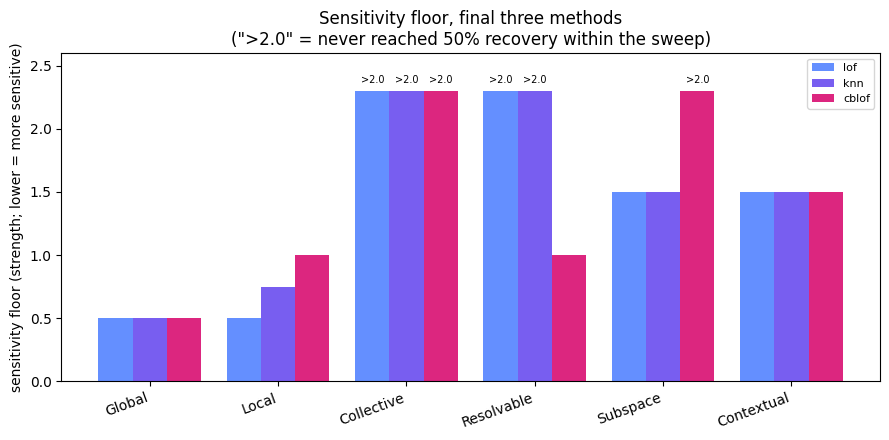

Saved: reports/Phase 1/figures/sensitivity_floor_bars.png
Saved: data/processed/phase_1/catalog2_sensitivity_floor_final3.csv


In [12]:
FINAL_METHODS = ['lof', 'knn', 'cblof']
GEOM_ORDER = ['A_global', 'B_local', 'C_collective', 'C_separated', 'D_subspace', 'E_contextual']
GEOM_LABELS = ['Global', 'Local', 'Collective', 'Resolvable', 'Subspace', 'Contextual']

# Self-contained rather than relying on the recovery-curves cell's METHOD_COLORS: this cell
# runs before that one in notebook order, so it can't assume that name already exists.
METHOD_COLORS = {
    'lof':          '#648FFF',  # IBM blue
    'knn':          '#785EF0',  # IBM purple
    'cblof':        '#DC267F',  # IBM magenta
    'subspace':     '#FE6100',  # IBM orange
    'subspace_max': '#FFB000',  # IBM gold
    'eif':          '#666666',  # added, IBM set is 5, seven methods need two more
    'cad':          '#e377c2',  # added, default-cycle pink, not otherwise used
}

floor_final = floor_df.loc[FINAL_METHODS, GEOM_ORDER]

# '>2.0' means the method never reached 50% recovery within the tested sweep; capped above the
# sweep range and text-labelled so it reads as a sentinel, not a real measured value.
STRENGTH_CAP = 2.3
numeric = floor_final.replace('>2.0', STRENGTH_CAP).astype(float)
is_capped = floor_final == '>2.0'

x = np.arange(len(GEOM_ORDER))
width = 0.8 / len(FINAL_METHODS)

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, method in enumerate(FINAL_METHODS):
    heights = numeric.loc[method].to_numpy()
    capped = is_capped.loc[method].to_numpy()
    positions = x + i * width
    ax.bar(positions, heights, width, label=method, color=METHOD_COLORS[method])
    for pos, height, cap in zip(positions, heights, capped):
        if cap:
            ax.text(pos, height + 0.05, '>2.0', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * (len(FINAL_METHODS) - 1) / 2)
ax.set_xticklabels(GEOM_LABELS, rotation=20, ha='right')
ax.set_ylabel('sensitivity floor (strength; lower = more sensitive)')
ax.set_ylim(0, STRENGTH_CAP + 0.3)
ax.set_title('Sensitivity floor, final three methods\n(">2.0" = never reached 50% recovery within the sweep)')
ax.legend(fontsize=8)
plt.tight_layout()
fig_path = PROJECT / 'reports' / 'Phase 1' / 'figures' / 'sensitivity_floor_bars.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.relative_to(PROJECT)}')

out = PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog2_sensitivity_floor_final3.csv'
floor_final.to_csv(out)
print(f'Saved: {out.relative_to(PROJECT)}')


## Recovery curves

One panel per anomaly type; all six methods overlaid. The x-axis is anomaly strength
(multiplier on the empirical anchor), the y-axis is mean top-5% recovery rate. Error
bands show ±1 std across the 5 repeats.

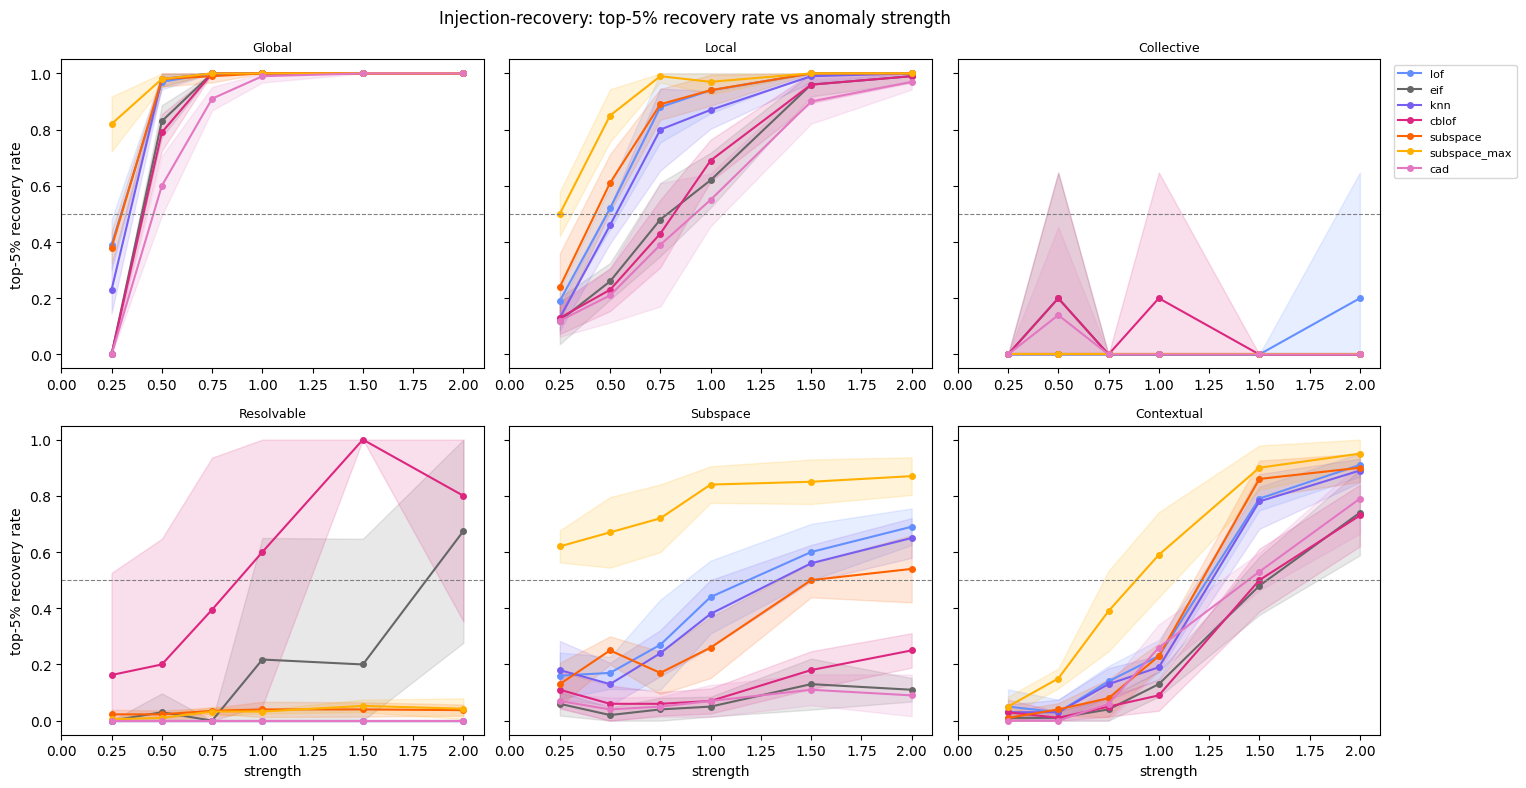

Saved: reports/Phase 1/figures/injection_recovery_curves.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
fig.suptitle('Injection-recovery: top-5% recovery rate vs anomaly strength', fontsize=12)

for idx, (ax, type_name) in enumerate(zip(axes.flat, GENERATORS)):
    sub = summary[summary['type'] == type_name]
    for method in METHODS:
        m = sub[sub['method'] == method].sort_values('strength')
        ax.plot(m['strength'], m['mean_rec'], color=METHOD_COLORS[method],
                label=method, marker='o', ms=4)
        ax.fill_between(
            m['strength'],
            (m['mean_rec'] - m['std_rec']).clip(0, 1),
            (m['mean_rec'] + m['std_rec']).clip(0, 1),
            color=METHOD_COLORS[method], alpha=0.15
        )
    ax.axhline(0.5, color='grey', lw=0.8, ls='--')
    ax.set_title(TYPE_TITLES[type_name], fontsize=9)
    ax.set_xlim(0, 2.1)
    ax.set_ylim(-0.05, 1.05)
    if idx >= 3:
        ax.set_xlabel('strength')
    if idx % 3 == 0:
        ax.set_ylabel('top-5% recovery rate')

plt.tight_layout()

# Anchored to the top-right panel's own axes (transAxes), not the whole figure, so it sits
# right against the plots instead of floating out in figure-fraction space.
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[2].legend(handles, labels, fontsize=8, bbox_to_anchor=(1.02, 1.0), loc='upper left')

fig_path = PROJECT / 'reports' / 'Phase 1' / 'figures' / 'injection_recovery_curves.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.relative_to(PROJECT)}')

## Interpretation

The sensitivity floor table is read against the geometry each method is designed to
detect:

- A method **earns its place** if it reaches a sensitivity floor <= 1.0 on at least one
  anomaly type for which it is the target detector, and its floor is clearly lower than
  that of methods with the wrong inductive bias for that type.
- A method is **redundant** if its recovery profile on every anomaly type is dominated by
  another method in the set (a lower floor everywhere, or an indistinguishable one).
- A type is a **blind spot** if no method reaches a floor <= 1.0 for it, indicating that
  the current set cannot reliably recover anomalies of that geometry even at the level of
  the most extreme real burst.

Expected pattern given the methods' inductive biases:

- LOF dominates Type B. Its behaviour on Type C depends on whether the knot is larger than
  its neighbourhood size k: a knot smaller than k is still flagged, so the "density method is
  blind to a micro-cluster" effect only appears once the cluster exceeds k.
- EIF and kNN dominate Type A.
- CBLOF dominates Type C and is weaker on Types A and B.
- The subspace ensemble dominates Type D, where the other methods are expected to fail.
- CAD dominates Type E, where the other methods are expected to fail.

Redundancy between CBLOF and EIF/kNN on Types A and B is expected and acceptable; CBLOF's
distinct contribution is Type C coverage, which the other methods miss by construction.